In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

In [13]:
df = pd.read_csv('../../spreadsheets/HousingData.csv')
df = df[['CRIM', 'RM', 'DIS', 'TAX', 'MEDV']]
df

,CRIM,RM,DIS,TAX,MEDV
0,0.00632,6.575,4.0900,296,24.0
1,0.02731,6.421,4.9671,242,21.6
2,0.02729,7.185,4.9671,242,34.7
3,0.03237,6.998,6.0622,222,33.4
4,0.06905,7.147,6.0622,222,36.2
...,...,...,...,...,...
501,0.06263,6.593,2.4786,273,22.4
502,0.04527,6.120,2.2875,273,20.6
503,0.06076,6.976,2.1675,273,23.9
504,0.10959,6.794,2.3889,273,22.0


In [14]:
titles = ['crime rate', 'number of rooms', 'average distance', 'property tax', 'housing price']

In [19]:
grp = pd.Series(['M' for i in range(len(df))])
grp.loc[df.MEDV >= 25.0] = 'H'
grp.loc[df.MEDV <= 17.0] = 'L'
df['grp'] = grp

In [20]:
new_odr = ['H', 'M', 'L']
new_dtype = CategoricalDtype(categories=new_odr, ordered=True)
df.grp = df.grp.astype(new_dtype)
df.grp.dtype

CategoricalDtype(categories=['H', 'M', 'L'], ordered=True, categories_dtype=str)

C:\Users\superuser\AppData\Local\Temp\ipykernel_1724\1161632653.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


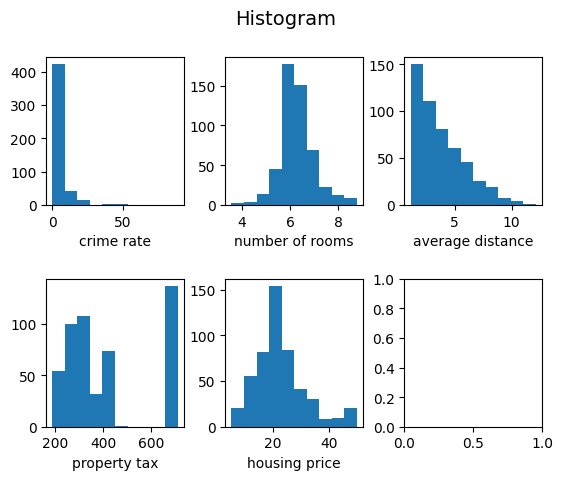

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=3)
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for i in range(5):
    df[df.columns[i]].plot.hist(ax=axes[i//3,i%3],
                                ylabel='', xlabel=titles[i])
    
fig.suptitle('Histogram', fontsize=14)
fig.show()

C:\Users\superuser\AppData\Local\Temp\ipykernel_1724\4000343094.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


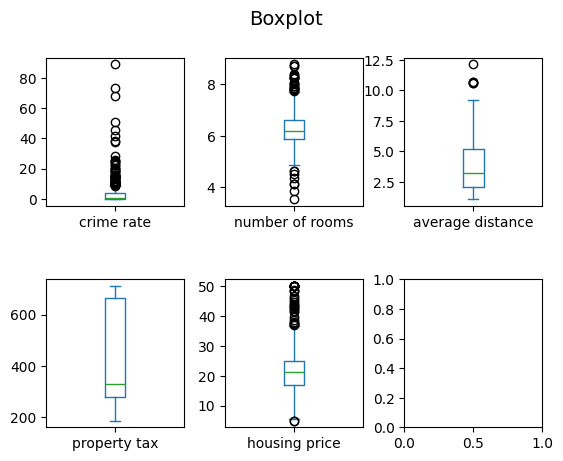

In [24]:
# Box plot diri dapita part
fig, axes = plt.subplots(nrows=2, ncols=3)
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for i in range(5):
    df[df.columns[i]].plot.box(ax=axes[i//3,i%3], label=titles[i])
    
fig.suptitle('Boxplot', fontsize=14)
fig.show()

C:\Users\superuser\AppData\Local\Temp\ipykernel_1724\1214511372.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


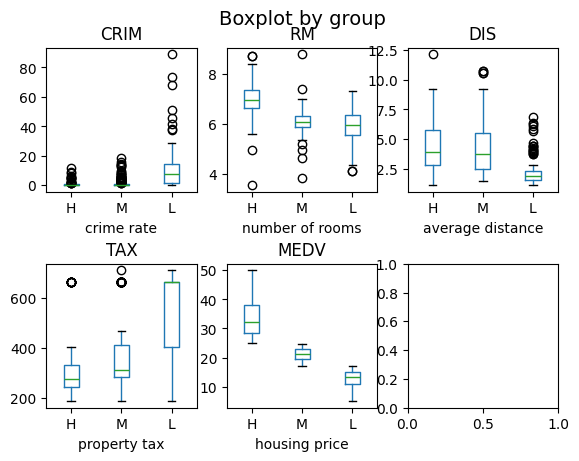

In [25]:
fig, axes = plt.subplots(nrows=2, ncols =3)
fig.subplots_adjust(hspace =0.5,wspace=0.3) 
for i in range(5) :
    df.boxplot(column= df.columns[i], by='grp', grid=False,
                  ax=axes[i//3,i%3], xlabel =titles[i])
fig.suptitle('Boxplot by group', fontsize =14)
fig.show()

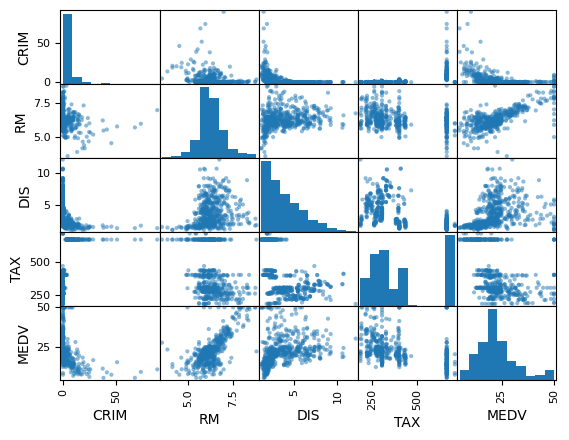

In [26]:
pd.plotting.scatter_matrix(df.iloc [:,:5])
plt.show()